# Heart Sound Classification - Prediction using Trained Model

This notebook loads a pre-trained `.h5` model and predicts the class of an uploaded `.wav` heart sound audio file.

**Steps:**
1. Install dependencies
2. Upload the trained model (`.h5` file)
3. Define class labels
4. Upload a `.wav` audio file
5. Sensor spectral correction (ESP32 -> Reference)
6. Extract MFCC features and visualize
7. Preprocess and predict
8. Detailed prediction probabilities

## Step 1: Install and Import Dependencies

In [1]:
!pip install librosa numpy matplotlib -q
!pip install tf_keras -q

In [2]:
import os
# Force TensorFlow to use Keras 2 (legacy) — required for loading .h5 models trained with Keras 2
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
import tf_keras as keras
from google.colab import files
import IPython.display as ipd

print("TensorFlow version:", tf.__version__)
print("All dependencies loaded successfully!")

TensorFlow version: 2.19.0
All dependencies loaded successfully!


## Step 2: Upload the Trained Model (.h5 file)

Upload your `model_fold_5 (3).h5` file when prompted.

In [3]:
# Upload the .h5 model file
print("Please upload your trained model (.h5 file):")
uploaded_model = files.upload()

# Get the uploaded model filename
model_filename = list(uploaded_model.keys())[0]
print(f"\nModel file uploaded: {model_filename}")

# Load the model using tf_keras (Keras 2 compatible)
model = keras.models.load_model(model_filename)
print("Model loaded successfully!")
print(f"\nModel Input Shape: {model.input_shape}")
print(f"Model Output Shape: {model.output_shape}")
print(f"Number of classes: {model.output_shape[-1]}")
model.summary()

Please upload your trained model (.h5 file):


Saving best_model_fold_2.h5 to best_model_fold_2.h5

Model file uploaded: best_model_fold_2.h5
Model loaded successfully!

Model Input Shape: (None, 13, 47, 1)
Model Output Shape: (None, 5)
Number of classes: 5
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_8 (Conv1D)           (None, 13, 45, 128)       512       
                                                                 
 conv1d_9 (Conv1D)           (None, 13, 43, 128)       49280     
                                                                 
 conv1d_10 (Conv1D)          (None, 13, 41, 128)       49280     
                                                                 
 conv1d_11 (Conv1D)          (None, 13, 39, 128)       49280     
                                                                 
 conv1d_12 (Conv1D)          (None, 13, 37, 128)       49280     
                                         

## Step 3: Define Class Labels

**IMPORTANT:** Update the `CLASS_LABELS` list below to match the exact class names used during training (in alphabetical order, since `LabelEncoder` sorts labels alphabetically).

In [10]:
# ============================================================
# UPDATE THESE CLASS LABELS TO MATCH YOUR TRAINING DATA
# Labels must be in ALPHABETICAL order (LabelEncoder default)
# ============================================================
CLASS_LABELS = ["AS", "MR", "MS", "MVP", "N"]
# ============================================================

num_classes = model.output_shape[-1]
assert len(CLASS_LABELS) == num_classes, \
    f"ERROR: You defined {len(CLASS_LABELS)} labels but the model expects {num_classes} classes. Please update CLASS_LABELS."

print(f"Number of classes: {num_classes}")
print(f"Class labels: {CLASS_LABELS}")

Number of classes: 5
Class labels: ['AS', 'MR', 'MS', 'MVP', 'N']


## Step 4: Upload a .wav Audio File for Prediction

In [35]:
# Upload a .wav audio file
print("Please upload a .wav audio file for prediction:")
uploaded_audio = files.upload()

# Get the uploaded audio filename
audio_filename = list(uploaded_audio.keys())[0]
print(f"\nAudio file uploaded: {audio_filename}")

# Load and play the audio
signal, sr = librosa.load(audio_filename, sr=None, duration=3.0)
print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(signal)/sr:.2f} seconds")
print(f"Signal shape: {signal.shape}")

# Play the audio
print("\nPlaying ORIGINAL audio:")
ipd.display(ipd.Audio(signal, rate=sr))

Please upload a .wav audio file for prediction:


Saving clean_heartbeat8KNEW (4).wav to clean_heartbeat8KNEW (4).wav

Audio file uploaded: clean_heartbeat8KNEW (4).wav
Sample Rate: 8000 Hz
Duration: 3.00 seconds
Signal shape: (24000,)

Playing ORIGINAL audio:


## Step 5: Sensor Spectral Correction (ESP32 -> Reference)

This step applies a frequency-domain equalization to correct for the difference in frequency response between the ESP32 MEMS microphone and the reference dataset's recording device. **Skip this cell if your audio comes from the reference dataset.**

In [36]:
from scipy.signal import butter, sosfiltfilt

# Pre-computed sensor correction curve (ESP32 INMP441 -> Reference device)
SENSOR_CORRECTION_FREQS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120,
                           140, 160, 180, 200, 250, 300, 350, 400]
SENSOR_CORRECTION_GAINS = [4.6871, 2.4887, 0.7794, 0.4272, 0.3144, 0.4263,
                           0.7918, 1.3655, 1.9014, 2.5745, 4.1475, 6.1216,
                           4.8266, 2.9063, 3.3069, 2.7223, 1.3686, 1.2549,
                           2.9471, 5.378]

def apply_sensor_correction(data, sample_rate):
    """Apply spectral equalization to match reference dataset sensor characteristics."""
    n = len(data)
    fft_data = np.fft.rfft(data)
    freqs = np.fft.rfftfreq(n, 1.0 / sample_rate)

    # Interpolate correction curve to FFT bin frequencies
    correction = np.interp(freqs, SENSOR_CORRECTION_FREQS, SENSOR_CORRECTION_GAINS,
                           left=SENSOR_CORRECTION_GAINS[0], right=1.0)

    # Apply correction and transform back
    corrected = np.fft.irfft(fft_data * correction, n=n)

    # Bandpass filter (25-400 Hz)
    nyq = 0.5 * sample_rate
    sos = butter(4, [25.0 / nyq, 400.0 / nyq], btype='band', output='sos')
    corrected = sosfiltfilt(sos, corrected)

    # Normalize to [-1, 1]
    max_amp = np.max(np.abs(corrected))
    if max_amp > 0:
        corrected = corrected / max_amp

    return corrected.astype(np.float32)

# Apply sensor correction
print("Applying sensor spectral correction...")
signal = apply_sensor_correction(signal, sr)

print(f"Corrected signal shape: {signal.shape}")
print(f"Corrected signal range: [{signal.min():.4f}, {signal.max():.4f}]")

# Play corrected audio
print("\nPlaying CORRECTED audio:")
ipd.display(ipd.Audio(signal, rate=sr))

Applying sensor spectral correction...
Corrected signal shape: (24000,)
Corrected signal range: [-0.9288, 1.0000]

Playing CORRECTED audio:


## Step 6: Extract MFCC Features and Visualize

MFCC shape: (13, 47)


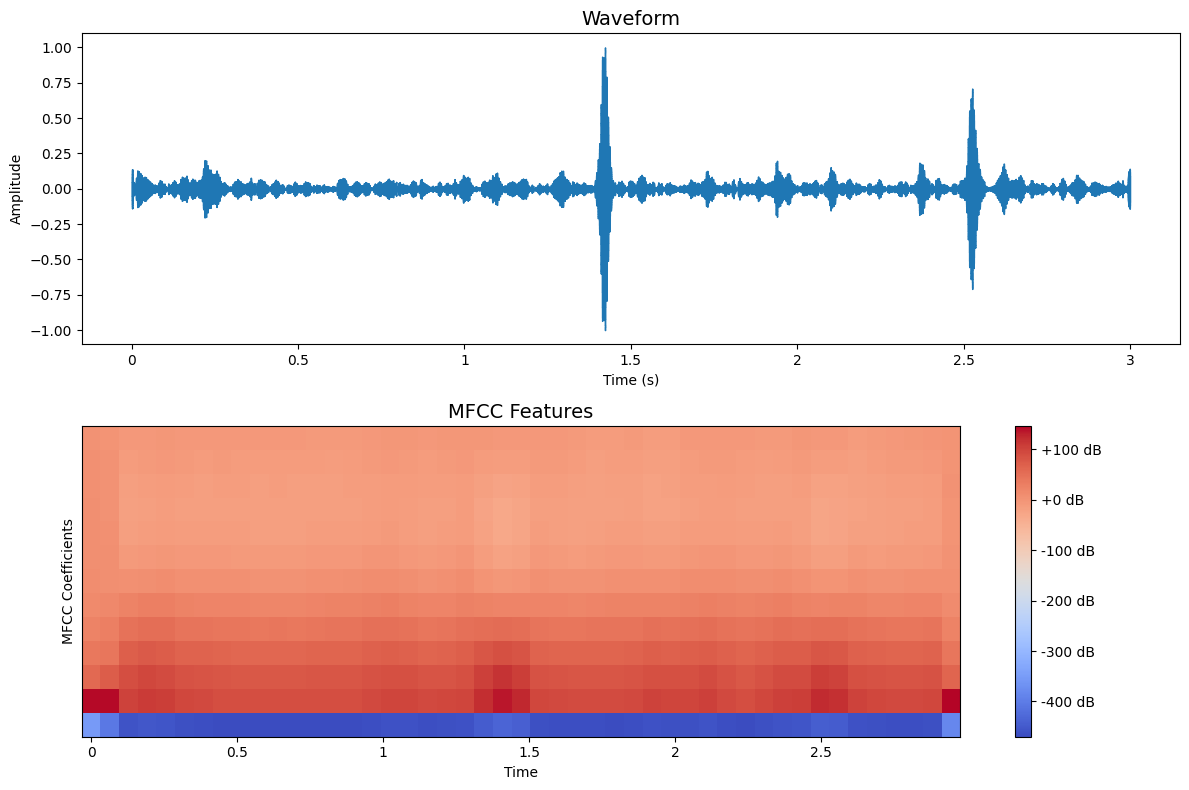

In [37]:
# Extract MFCCs (same as training: 13 coefficients)
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
print(f"MFCC shape: {mfccs.shape}")

# Visualize the waveform and MFCCs
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
axes[0].set_title("Waveform", fontsize=14)
librosa.display.waveshow(signal, sr=sr, ax=axes[0])
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# MFCCs
img = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[1])
axes[1].set_title("MFCC Features", fontsize=14)
axes[1].set_ylabel("MFCC Coefficients")
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## Step 7: Preprocess and Predict

In [38]:
# Reshape MFCCs to match the model's expected input shape
# Training code used: expand_dims at axis=3 on (n_samples, 13, n_frames)
# So model expects: (batch_size, 13, n_frames, 1)

expected_input_shape = model.input_shape  # (None, dim1, dim2, dim3)
print(f"Model expects input shape: {expected_input_shape}")
print(f"Raw MFCC shape: {mfccs.shape}")

# Match the expected number of time frames from the model
expected_frames = expected_input_shape[2]
current_frames = mfccs.shape[1]

if current_frames < expected_frames:
    # Pad with zeros if audio is shorter
    mfccs_padded = np.pad(mfccs, ((0, 0), (0, expected_frames - current_frames)), mode='constant')
    print(f"Padded MFCCs from {current_frames} to {expected_frames} frames")
elif current_frames > expected_frames:
    # Truncate if audio is longer
    mfccs_padded = mfccs[:, :expected_frames]
    print(f"Truncated MFCCs from {current_frames} to {expected_frames} frames")
else:
    mfccs_padded = mfccs
    print("MFCC frames match expected shape exactly")

# Reshape: add batch dimension and channel dimension
# (13, n_frames) -> (1, 13, n_frames, 1)
input_data = np.expand_dims(mfccs_padded, axis=0)   # batch dimension
input_data = np.expand_dims(input_data, axis=3)      # channel dimension

print(f"Final input shape: {input_data.shape}")

# Predict
predictions = model.predict(input_data)
predicted_class_index = np.argmax(predictions[0])
predicted_class_label = CLASS_LABELS[predicted_class_index]
confidence = predictions[0][predicted_class_index] * 100

print("\n" + "="*50)
print(f"  PREDICTED CLASS: {predicted_class_label}")
print(f"  CONFIDENCE: {confidence:.2f}%")
print("="*50)

Model expects input shape: (None, 13, 47, 1)
Raw MFCC shape: (13, 47)
MFCC frames match expected shape exactly
Final input shape: (1, 13, 47, 1)
1/1 [==============================] - 0s 33ms/step

  PREDICTED CLASS: N
  CONFIDENCE: 99.93%


## Step 8: Detailed Prediction Probabilities

Prediction Probabilities for Each Class:
----------------------------------------
     AS:   0.00% |
     MR:   0.03% |
     MS:   0.03% |
    MVP:   0.01% |
      N:  99.93% |################################################# <-- PREDICTED
----------------------------------------


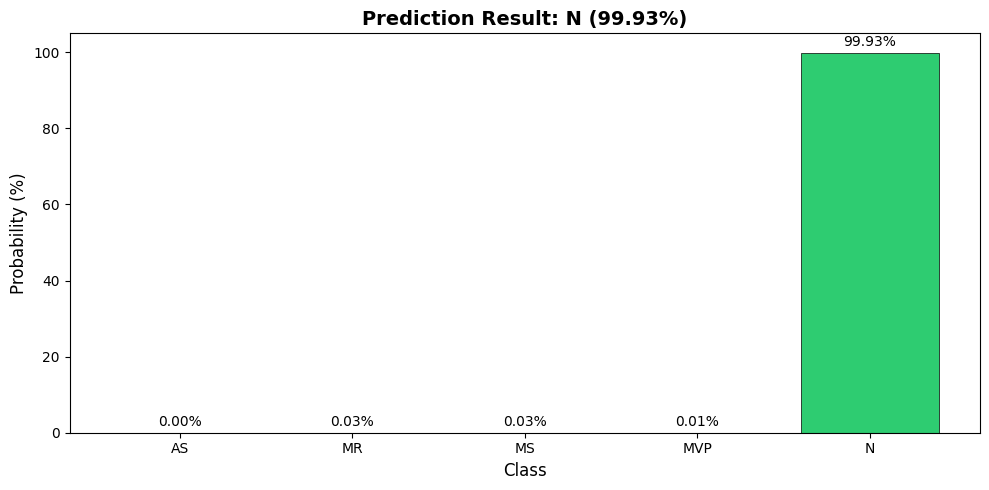

In [39]:
# Display prediction probabilities for all classes
print("Prediction Probabilities for Each Class:")
print("-" * 40)
for i, (label, prob) in enumerate(zip(CLASS_LABELS, predictions[0])):
    bar = "#" * int(prob * 50)
    marker = " <-- PREDICTED" if i == predicted_class_index else ""
    print(f"  {label:>5s}: {prob*100:6.2f}% |{bar}{marker}")
print("-" * 40)

# Bar chart visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if i == predicted_class_index else '#3498db' for i in range(num_classes)]
bars = ax.bar(CLASS_LABELS, predictions[0] * 100, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Probability (%)", fontsize=12)
ax.set_title(f"Prediction Result: {predicted_class_label} ({confidence:.2f}%)", fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)

# Add percentage labels on bars
for bar, prob in zip(bars, predictions[0]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{prob*100:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()